In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('tiktok_dataset.csv')

In [3]:
df.head(10)

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
5,6,claim,8972200955,35,someone shared with me that gross domestic pro...,not verified,under review,336647.0,175546.0,62303.0,4293.0,1857.0
6,7,claim,4958886992,16,someone shared with me that elvis presley has ...,not verified,active,750345.0,486192.0,193911.0,8616.0,5446.0
7,8,claim,2270982263,41,someone shared with me that the best selling s...,not verified,active,547532.0,1072.0,50.0,22.0,11.0
8,9,claim,5235769692,50,someone shared with me that about half of the ...,not verified,active,24819.0,10160.0,1050.0,53.0,27.0
9,10,claim,4660861094,45,someone shared with me that it would take a 50...,verified,active,931587.0,171051.0,67739.0,4104.0,2540.0


In [4]:
df.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [6]:
##Question 1: Each row represents a different claim that was filed about a video that needs to be reviewed.
##Question 2: Out of 12 columns, there are 3 integer types, 4 object types, and 5 float types. Any column without 19,382 nonnull entries will have null values. These are:
##claim status(object), video_transcription_text(object), and video_view_count, video_like_count, video_share_count, video_download_count, cideo_comment_count (all float).
##Question 3: There do seem to be some outliers in the video_view_count, video_like_count, and video_share_count. This conclusion is drawn simply by looking at the max value and
##looking at how large it is comapred to the 50% and 75% quartile. However, it also makes sense that if a video was flagged by users, this could be a reason why.

In [7]:
df['claim_status'].unique()

array(['claim', 'opinion', nan], dtype=object)

In [8]:
## Threre are three claim types (if counting nan)-> 'claim', 'opinion', 'nan

In [9]:
len(df[df['claim_status'] == 'claim'])

9608

In [10]:
len(df[df['claim_status'] == 'opinion'])

9476

In [11]:
len(df[df['claim_status'].isna()])

298

In [12]:
##The number of claim_status claims is 9608, the number of claim_satus opinion is 9476, and the nan value is 298. It is interesting that the claim value and the opinion value are almost
##identical

In [13]:
print(f'The average video view count for claim_status = "claim" is', str(df[df['claim_status'] == 'claim']['video_view_count'].mean().round(2)))
print(f'The median video view count for claim_status = "claim" is', str(df[df['claim_status'] == 'claim']['video_view_count'].median().round(2)))

The average video view count for claim_status = "claim" is 501029.45
The median video view count for claim_status = "claim" is 501555.0


In [14]:
print(f'The average video view count for claim_status = "opinion" is', str(df[df['claim_status'] == 'opinion']['video_view_count'].mean().round(2)))
print(f'The median video view count for claim_status = "opinion" is', str(df[df['claim_status'] == 'opinion']['video_view_count'].median().round(2)))

The average video view count for claim_status = "opinion" is 4956.43
The median video view count for claim_status = "opinion" is 4953.0


In [15]:
##Question 4: For the videos where the claim_status is a claim, as opposed to an opinion, viewership is just over 100x as much.

In [16]:
df['author_ban_status'].unique()

array(['under review', 'active', 'banned'], dtype=object)

In [17]:
df.groupby('claim_status')['author_ban_status'].value_counts()

claim_status  author_ban_status
claim         active               6566
              under review         1603
              banned               1439
opinion       active               8817
              under review          463
              banned                196
Name: count, dtype: int64

In [18]:
##Question: Threre are much much more ative opinion claims, however, the under review claims are approximatley 4x less and the number of banned authors is more than 10x less.

In [19]:
df.groupby('author_ban_status')['video_share_count'].median()

author_ban_status
active            437.0
banned          14468.0
under review     9444.0
Name: video_share_count, dtype: float64

In [20]:
##Question: Based on the median of video share count, there are almost 31x less active authors then there are banned authors

In [21]:
df.groupby('author_ban_status')[['video_share_count']].agg(['count','mean', 'median']).round(2)

video_share_count                   
                              count      mean   median
author_ban_status                                     
active                        15383  14111.47    437.0
banned                         1635  29998.94  14468.0
under review                   2066  25774.70   9444.0

In [22]:
df.groupby('author_ban_status')[['video_view_count']].agg(['count','mean', 'median']).round(2)

video_view_count                     
                             count       mean    median
author_ban_status                                      
active                       15383  215927.04    8616.0
banned                        1635  445845.44  448201.0
under review                  2066  392204.84  365245.5

In [23]:
df.groupby('author_ban_status')[['video_like_count']].agg(['count','mean', 'median']).round(2)

video_like_count                     
                             count       mean    median
author_ban_status                                      
active                       15383   71036.53    2222.0
banned                        1635  153017.24  105573.0
under review                  2066  128718.05   71204.5

In [24]:
df.groupby(['claim_status','author_ban_status']).agg({'video_share_count': ['count','mean','median'], 'video_view_count': ['count','mean','median'],
                                                     'video_like_count': ['count','mean','median']})

video_share_count                         \
                                           count          mean   median   
claim_status author_ban_status                                            
claim        active                         6566  32769.101889  17774.5   
             banned                         1439  34056.580959  19018.0   
             under review                   1603  33155.623206  18084.0   
opinion      active                         8817    217.166950    121.0   
             banned                          196    208.423469    108.5   
             under review                    463    220.431965    124.0   

                               video_view_count                           \
                                          count           mean    median   
claim_status author_ban_status                                             
claim        active                        6566  499221.733171  499500.5   
             banned                        1439  505907.917304  512572.0   
             under review                  1603  504054.640674  500774.0   
opinion      active                        8817    4958.120563    4958.0   
             banned                         196    4876.530612    5083.5   
             under review                   463    4958.105832    4884.0   

                               video_like_count                           
                                          count           mean    median  
claim_status author_ban_status                                            
claim        active                        6566  164960.302924  121943.0  
             banned                        1439  173719.102849  132044.0  
             under review                  1603  165566.954460  125882.0  
opinion      active                        8817    1091.714982     820.0  
             banned                         196    1027.515306     799.5  
             under review                   463    1139.663067     876.0

In [25]:
##Question: Based on the previous three tables created, the number of likes, views, and shares are greatly increased for baneed authors than active authors.

In [26]:
df['likes_per_view'] = (df['video_like_count']/df['video_view_count'])
df['comments_per_view'] = (df['video_comment_count']/df['video_view_count'])
df['shares_per_view'] = (df['video_share_count']/df['video_view_count'])
df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,likes_per_view,comments_per_view,shares_per_view
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,0.056584,0.000000,0.000702
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,0.549096,0.004855,0.135111
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,0.108282,0.000365,0.003168
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,0.548459,0.001335,0.079569
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,0.622910,0.002706,0.073175


In [27]:
df.groupby(['claim_status','author_ban_status']).agg({'likes_per_view': ['count', 'mean', 'median'], 
                                                      'comments_per_view': ['count', 'mean', 'median'], 'shares_per_view': ['count', 'mean', 'median']})

likes_per_view                      \
                                        count      mean    median   
claim_status author_ban_status                                      
claim        active                      6566  0.329542  0.326538   
             banned                      1439  0.345071  0.358909   
             under review                1603  0.327997  0.320867   
opinion      active                      8817  0.219744  0.218330   
             banned                       196  0.206868  0.198483   
             under review                 463  0.226394  0.228051   

                               comments_per_view                      \
                                           count      mean    median   
claim_status author_ban_status                                         
claim        active                         6566  0.001393  0.000776   
             banned                         1439  0.001377  0.000746   
             under review                   1603  0.001367  0.000789   
opinion      active                         8817  0.000517  0.000252   
             banned                          196  0.000434  0.000193   
             under review                    463  0.000536  0.000293   

                               shares_per_view                      
                                         count      mean    median  
claim_status author_ban_status                                      
claim        active                       6566  0.065456  0.049279  
             banned                       1439  0.067893  0.051606  
             under review                 1603  0.065733  0.049967  
opinion      active                       8817  0.043729  0.032405  
             banned                        196  0.040531  0.030728  
             under review                  463  0.044472  0.035027

In [28]:
##Question: Claim rates and opinion differ greatly as across the board the claim rates seem to have the most amount of likes, shares, views, etc. However, these vides also have the
##greatest number of banned authors by a very large margin.

In [29]:
## This section starts the work for module 2: EDA and Plotting to help further understand the data

In [30]:
df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,likes_per_view,comments_per_view,shares_per_view
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,0.056584,0.000000,0.000702
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,0.549096,0.004855,0.135111
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,0.108282,0.000365,0.003168
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,0.548459,0.001335,0.079569
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,0.622910,0.002706,0.073175


In [31]:
df.size

290730

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
 12  likes_per_view            19084 non-null  float64
 13  comments_per_view         19084 non-null  float64
 14  shares

In [33]:
df.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,likes_per_view,comments_per_view,shares_per_view
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146,0.276093,0.000954,0.054860
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865,0.173006,0.001326,0.050597
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000,0.130240,0.000098,0.014445
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000,0.264037,0.000455,0.039739
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000,0.398482,0.001268,0.081864
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000,0.666648,0.010280,0.265956


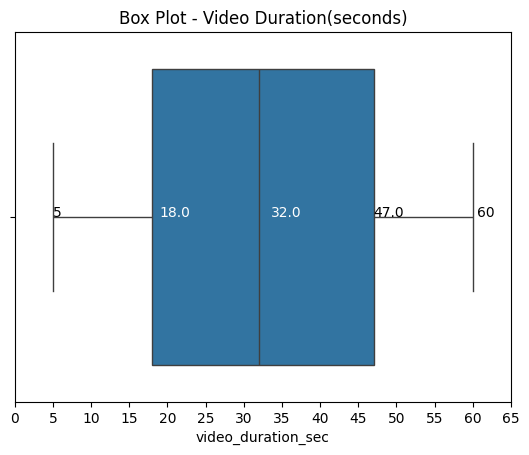

In [34]:
sns.boxplot(data=df, x=df['video_duration_sec'])

plt.title('Box Plot - Video Duration(seconds)')
plt.xticks(np.arange(0, 70, 5))

median = df['video_duration_sec'].median()
q1_duration = np.percentile(df['video_duration_sec'], 25)
q3_duration = np.percentile(df['video_duration_sec'], 75)
max_duration = df['video_duration_sec'].max()
min_duration = df['video_duration_sec'].min()
plt.annotate(median, xy=(1.05*median,0), xytext=(1.05*median, 0), color='w')
plt.annotate(q1_duration, xy=(1.05*q1_duration, 0), xytext=(1.05*q1_duration, 0), color='w')
plt.annotate(q3_duration, xy=(1.05*q3_duration, 0), xytext=(q3_duration, 0))
plt.annotate(max_duration, xy=(1.01*max_duration, 0.5), xytext=(1.01*max_duration,0))
plt.annotate(min_duration, xy=(1.07*min_duration, 0.5), xytext=(min_duration, 0))

plt.show()

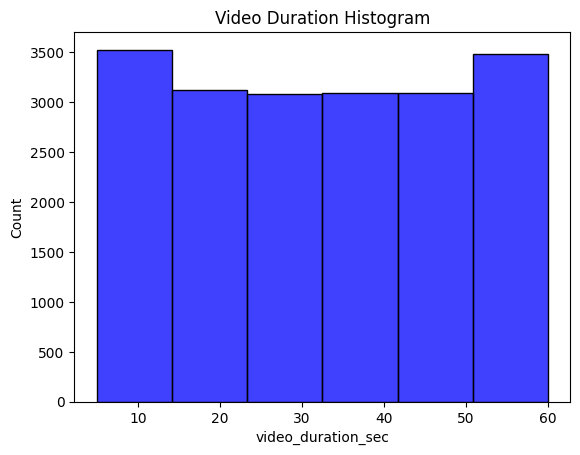

In [35]:
sns.histplot(data=df, x='video_duration_sec', binwidth=10, color='b')

plt.title('Video Duration Histogram')

plt.show()

In [36]:
##Since the 'video view count' column contains null values, cleaning them will be required to be able to get statistics for the set. The easiest way to do this is to
##simply remove the null values from the df. Reviewing the data shows tha other numerical values, aside from duration, tend to be nan. In addition, reviewing the data 
##shows that a large number of view counts are binned closer to lower end of the spectrum. I could assign all na values for this project to the mean, but i believe with the 
##outlier data and various other numericals also being nan that this will have very little effect and wont help uncover any specific trends.

In [37]:
df['video_view_count'].unique()

df_no_null = pd.notna(df['video_view_count'])
df_no_view_null = df[df_no_null]
df_no_view_null.tail()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,likes_per_view,comments_per_view,shares_per_view
19079,19080,opinion,1492320297,49,in our opinion the earth holds about 11 quinti...,not verified,active,6067.0,423.0,81.0,8.0,2.0,0.069721,0.000330,0.013351
19080,19081,opinion,9841347807,23,in our opinion the queens in ant colonies live...,not verified,active,2973.0,820.0,70.0,3.0,0.0,0.275816,0.000000,0.023545
19081,19082,opinion,8024379946,50,in our opinion the moon is moving away from th...,not verified,active,734.0,102.0,7.0,2.0,1.0,0.138965,0.001362,0.009537
19082,19083,opinion,7425795014,8,in our opinion lightning strikes somewhere on ...,not verified,active,3394.0,655.0,123.0,11.0,4.0,0.192988,0.001179,0.036240
19083,19084,opinion,4094655375,58,in our opinion a pineapple plant can only prod...,not verified,active,5034.0,815.0,281.0,11.0,1.0,0.161899,0.000199,0.055820


In [38]:
df_na = df[df['video_view_count'].isna()]
df_na.tail()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,likes_per_view,comments_per_view,shares_per_view
19377,19378,NaN,7578226840,21,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19378,19379,NaN,6079236179,53,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19379,19380,NaN,2565539685,10,NaN,verified,under review,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19380,19381,NaN,2969178540,24,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19381,19382,NaN,8132759688,13,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


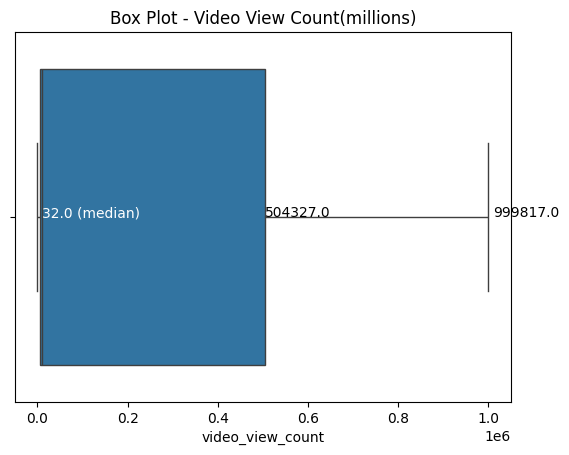

In [39]:
sns.boxplot(data=df_no_view_null, x=df_no_view_null['video_view_count'])

plt.title('Box Plot - Video View Count(millions)')

median_views = df_no_view_null['video_view_count'].median()
q1_views = np.percentile(df_no_view_null['video_view_count'], 25)
q3_views = np.percentile(df_no_view_null['video_view_count'], 75)
max_views = df_no_view_null['video_view_count'].max()
min_views = df_no_view_null['video_view_count'].min()

plt.annotate(f'{median} (median)', xy=(1.05*median_views,0), xytext=(1.05*median_views, 0), color='w')
# plt.annotate(q1, xy=(1.05*q1, 0), xytext=(1.05*q1, 0), color='w')
plt.annotate(q3_views, xy=(1.05*q3_views, 0), xytext=(q3_views, 0))
plt.annotate(max_views, xy=(1.01*max_views, 0.5), xytext=(1.01*max_views,0))
# plt.annotate(min, xy=(1.07*min, 0.5), xytext=(1.07*min, 0))

plt.show()

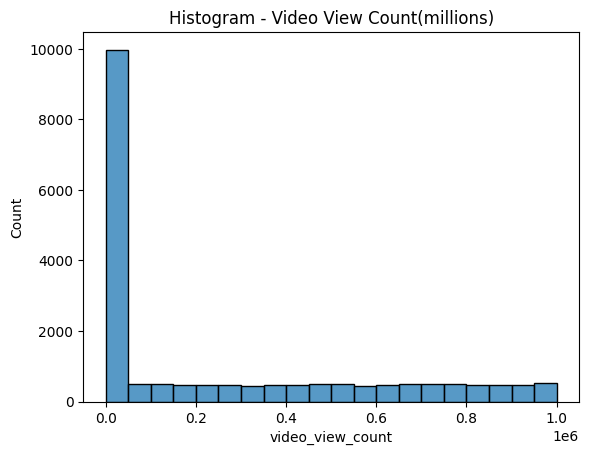

In [40]:
sns.histplot(df['video_view_count'],binwidth=50000)

plt.title('Histogram - Video View Count(millions)')

plt.show()

In [41]:
df_no_null_like = pd.notna(df['video_like_count'])
df_no_null_like_update = df[df_no_null_like]
df_no_null_like_update.sort_values(by='video_like_count', ascending=False).head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,likes_per_view,comments_per_view,shares_per_view
2446,2447,claim,9715423156,46,a friend read on an internet forum a claim th...,not verified,active,997365.0,657830.0,256130.0,4908.0,904.0,0.659568,0.000906,0.256807
9099,9100,claim,8377919455,7,i discovered on the news a claim that yellowst...,not verified,active,992667.0,656243.0,121155.0,6029.0,3277.0,0.661091,0.003301,0.122050
5285,5286,claim,6409213072,24,i read on an internet forum that j is the onl...,not verified,active,996499.0,654588.0,105992.0,13297.0,3010.0,0.656888,0.003021,0.106364
1322,1323,claim,8405710607,7,a colleague claimed the media discovered the l...,not verified,banned,993156.0,653561.0,249672.0,13771.0,5578.0,0.658065,0.005616,0.251393
3805,3806,claim,8240590198,45,someone read on an internet forum that a bana...,not verified,active,978322.0,649695.0,48652.0,637.0,106.0,0.664091,0.000108,0.049730


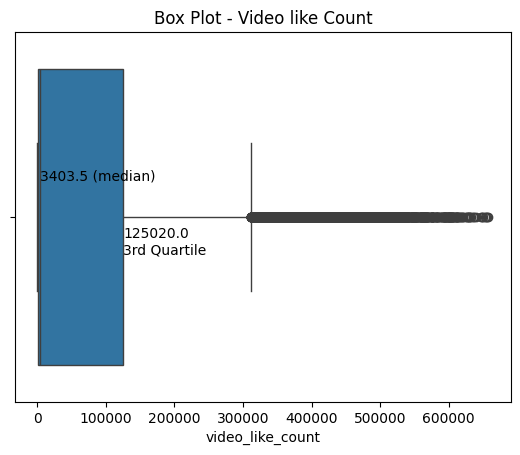

In [42]:
sns.boxplot(data=df_no_null_like_update, x=df_no_null_like_update['video_like_count'])

plt.title('Box Plot - Video like Count')

median_likes = df_no_null_like_update['video_like_count'].median()
q1_likes = np.percentile(df_no_null_like_update['video_like_count'], 25)
q3_likes = np.percentile(df_no_null_like_update['video_like_count'], 75)
max_likes = df_no_null_like_update['video_view_count'].max()
min_likes = df_no_null_like_update['video_view_count'].min()

plt.annotate(f'{median_likes} (median)', xy=(1.05*median_likes,0), xytext=(1.05*median_likes, -0.1))
# plt.annotate(q1, xy=(1.05*q1, 0), xytext=(1.05*q1, 0), color='w')
plt.annotate(f'{q3_likes}\n3rd Quartile', xy=(1.0*q3_likes, 0), xytext=(q3_likes, 0.1))
plt.annotate(max_likes, xy=(1.01*max_likes, 0.5), xytext=(1.01*max_likes,0))
# plt.annotate(min, xy=(1.07*min, 0.5), xytext=(1.07*min, 0))

plt.show()

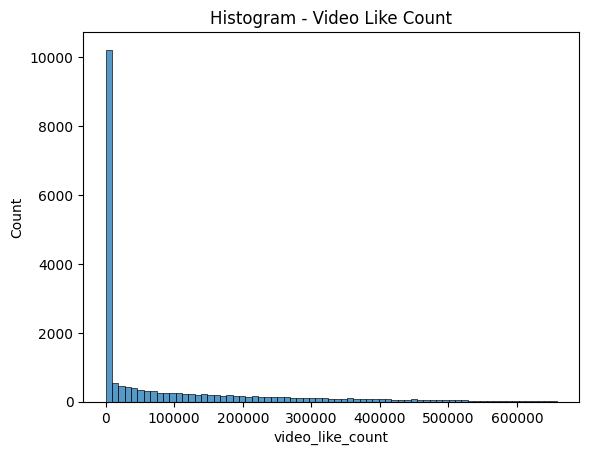

In [43]:
sns.histplot(data=df_no_null_like_update, x='video_like_count')
plt.title('Histogram - Video Like Count')
plt.show()

In [44]:
df_video_comment_mask = pd.notna(df['video_comment_count'])
df_no_null_video_comment = df[df_video_comment_mask]
df_no_null_video_comment.sort_values(by='video_comment_count', ascending=False).tail(10)
#df_no_null_video_comment.info()# Verify no null values remain, output not shown but is confirmed

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,likes_per_view,comments_per_view,shares_per_view
11727,11728,opinion,6576940704,35,my impression is that most children in the wor...,not verified,active,4991.0,172.0,55.0,2.0,0.0,0.034462,0.0,0.011020
11728,11729,opinion,7492997900,51,my impression is that humans are more likely t...,not verified,active,3329.0,1108.0,348.0,1.0,0.0,0.332833,0.0,0.104536
15585,15586,opinion,4031862651,53,my family's reasoning is that your fingernails...,not verified,active,3354.0,13.0,1.0,0.0,0.0,0.003876,0.0,0.000298
15587,15588,opinion,5934269738,33,my family's reasoning is that playing dance mu...,not verified,active,1565.0,134.0,32.0,3.0,0.0,0.085623,0.0,0.020447
19072,19073,opinion,3653523966,56,in our opinion bananas get their curved shape ...,not verified,active,5760.0,89.0,33.0,0.0,0.0,0.015451,0.0,0.005729
19077,19078,opinion,4635088632,50,in our opinion the human brain uses 20% of the...,not verified,active,3183.0,1233.0,95.0,3.0,0.0,0.387370,0.0,0.029846
19080,19081,opinion,9841347807,23,in our opinion the queens in ant colonies live...,not verified,active,2973.0,820.0,70.0,3.0,0.0,0.275816,0.0,0.023545
13387,13388,opinion,6107094080,33,our hypothesis is that a full jumbo jet tank h...,not verified,active,6490.0,18.0,2.0,0.0,0.0,0.002773,0.0,0.000308
13391,13392,opinion,6723909714,30,our hypothesis is that the eiffel tower leans ...,not verified,active,9934.0,297.0,44.0,1.0,0.0,0.029897,0.0,0.004429
13396,13397,opinion,5929111336,51,our hypothesis is that there are more than 24 ...,not verified,active,3388.0,5.0,1.0,0.0,0.0,0.001476,0.0,0.000295


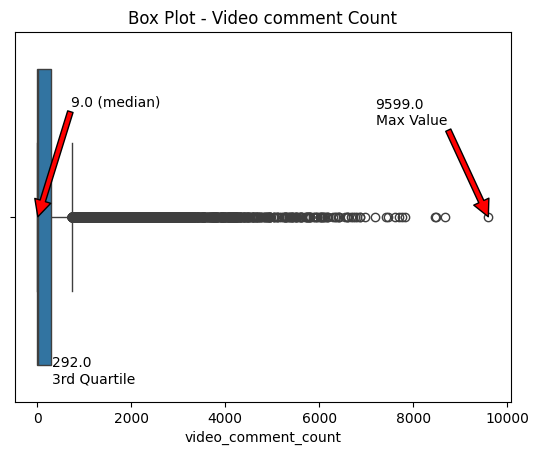

In [45]:
sns.boxplot(data=df_no_null_video_comment, x=df_no_null_video_comment['video_comment_count'])

plt.title('Box Plot - Video comment Count')

median_comments = df_no_null_video_comment['video_comment_count'].median()
q1_comments = np.percentile(df_no_null_video_comment['video_comment_count'], 25)
q3_comments = np.percentile(df_no_null_video_comment['video_comment_count'], 75)
max_comments = df_no_null_like_update['video_comment_count'].max()
min_comments = df_no_null_like_update['video_comment_count'].min()

plt.annotate(f'{median_comments} (median)', xy=(1.0*median_comments,0), xytext=(80*median_comments, -0.3), arrowprops=dict(facecolor='red'))
# plt.annotate(q1, xy=(1.05*q1, 0), xytext=(1.05*q1, 0), color='w')
plt.annotate(f'{q3_comments}\n3rd Quartile', xy=(q3_comments, 0), xytext=(1.03*q3_comments, 0.45))
plt.annotate(f'{max_comments}\nMax Value', xy=(1.0*max_comments, 0), xytext=(0.75*max_comments,-0.25), arrowprops=dict(facecolor='red'))
# plt.annotate(min, xy=(1.07*min, 0.5), xytext=(1.07*min, 0))

plt.show()

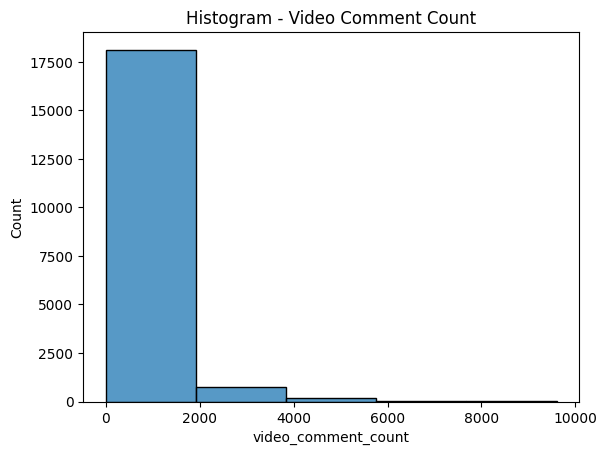

In [46]:
sns.histplot(df_no_null_video_comment['video_comment_count'], binwidth=2000)

plt.title('Histogram - Video Comment Count')

plt.show()

In [47]:
##Although the other graphs in this section tend to have a rightside tail off, this graph is overwhelmingly centered to the left, and making majority of the values in both the
##box plot and histogram look like outliers. Although there could be low values, i believe that the zeroes are skewing the data, and am going to take a look at what happens to this chart
##when the zero values are removed.

In [48]:
df_no_null_video_comment.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,likes_per_view,comments_per_view,shares_per_view
count,19084.000000,1.908400e+04,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9542.500000,5.624840e+09,32.423811,254708.558688,84304.636030,16735.248323,1049.429627,349.312146,0.276093,0.000954,0.054860
std,5509.220604,2.537030e+09,16.226470,322893.280814,133420.546814,32036.174350,2004.299894,799.638865,0.173006,0.001326,0.050597
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4771.750000,3.425100e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000,0.130240,0.000098,0.014445
50%,9542.500000,5.609500e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000,0.264037,0.000455,0.039739
75%,14313.250000,7.840823e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000,0.398482,0.001268,0.081864
max,19084.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000,0.666648,0.010280,0.265956


In [49]:
df_no_zeroes = df_no_null_video_comment[df_no_null_video_comment.apply(lambda x: x['video_comment_count'] != 0, axis=1)]
df_no_zeroes.describe()


,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,likes_per_view,comments_per_view,shares_per_view
count,15650.000000,1.565000e+04,15650.000000,15650.000000,15650.000000,15650.000000,15650.000000,15650.000000,15650.000000,15650.000000,15650.000000
mean,8543.256741,5.636351e+09,32.340511,308283.295847,102458.895527,20329.192843,1278.553802,425.959936,0.301731,0.001164,0.059918
std,5407.106870,2.539071e+09,16.224089,332198.903981,140775.167917,34288.584098,2146.284011,864.341076,0.171096,0.001378,0.052106
min,2.000000,1.235938e+09,5.000000,214.000000,32.000000,0.000000,1.000000,1.000000,0.000217,0.000001,0.000000
25%,3952.250000,3.429761e+09,18.000000,6928.250000,1559.000000,258.250000,18.000000,3.000000,0.162210,0.000256,0.018152
50%,7908.500000,5.623999e+09,32.000000,174961.500000,28648.500000,3172.500000,199.000000,40.000000,0.294508,0.000662,0.045792
75%,13042.250000,7.856307e+09,46.000000,596052.000000,164359.500000,26069.500000,1648.750000,441.000000,0.420892,0.001554,0.088849
max,19084.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000,0.666648,0.010280,0.265956


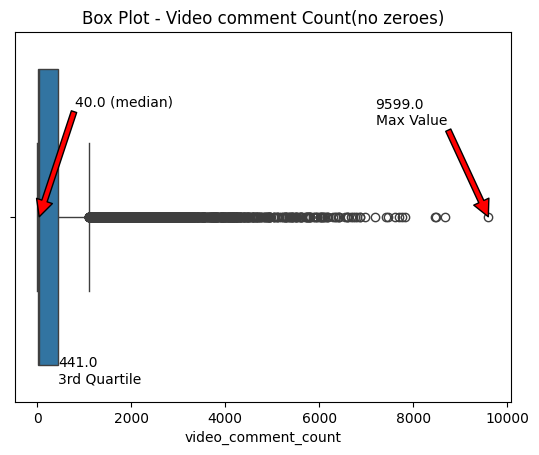

In [50]:
sns.boxplot(data=df_no_zeroes, x='video_comment_count')

plt.title('Box Plot - Video comment Count(no zeroes)')

median_comments = df_no_zeroes['video_comment_count'].median()
q1_comments = np.percentile(df_no_zeroes['video_comment_count'], 25)
q3_comments = np.percentile(df_no_zeroes['video_comment_count'], 75)
max_comments = df_no_zeroes['video_comment_count'].max()
min_comments = df_no_zeroes['video_comment_count'].min()

plt.annotate(f'{median_comments} (median)', xy=(1.0*median_comments,0), xytext=(20*median_comments, -0.3), arrowprops=dict(facecolor='red'))
# plt.annotate(q1, xy=(1.05*q1, 0), xytext=(1.05*q1, 0), color='w')
plt.annotate(f'{q3_comments}\n3rd Quartile', xy=(q3_comments, 0), xytext=(q3_comments, 0.45))
plt.annotate(f'{max_comments}\nMax Value', xy=(1.0*max_comments, 0), xytext=(0.75*max_comments,-0.25), arrowprops=dict(facecolor='red'))
# plt.annotate(min, xy=(1.07*min, 0.5), xytext=(1.07*min, 0))

plt.show()

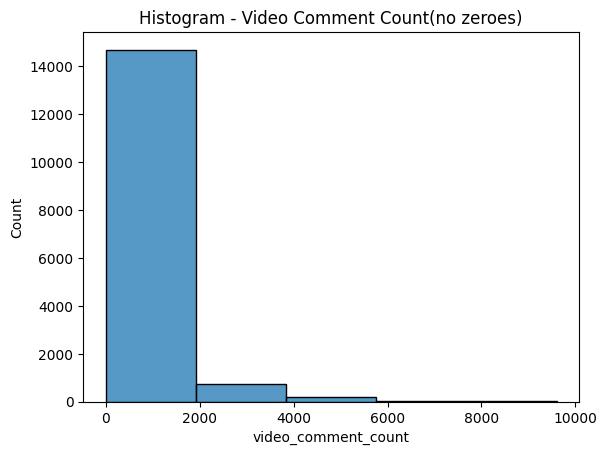

In [51]:
vcc = sns.histplot(data=df_no_zeroes, x='video_comment_count', binwidth=2000) ##vcc shorthand for video_comment_count

plt.title('Histogram - Video Comment Count(no zeroes)')

plt.show()

In [52]:
counts_comments = [p.get_height() for p in vcc.patches]
print(counts_comments)

[np.int64(14692), np.int64(734), np.int64(174), np.int64(43), np.int64(7)]


In [53]:
##Performing the drop shows a reduction of 3,434 data points, all with 0 comment count. Although the values of the mean and median increase as exepcted, this increase does support
##the claim that the zero values were misconstruing the data. The data still shows oulier values in the comment count, and per the histogram, this starts around the 60000 comment count
##where the video comment count drops off drastically from 174->43->7

In [54]:
df_video_share_mask = pd.notna(df['video_share_count'])
df_no_null_video_share = df[df_video_share_mask]
df_no_null_video_share.sort_values(by='video_share_count', ascending=False).head(10)
#df_no_null_video_share.info()# Verify no null values remain, output not shown but is confirmed

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,likes_per_view,comments_per_view,shares_per_view
2446,2447,claim,9715423156,46,a friend read on an internet forum a claim th...,not verified,active,997365.0,657830.0,256130.0,4908.0,904.0,0.659568,0.000906,0.256807
1322,1323,claim,8405710607,7,a colleague claimed the media discovered the l...,not verified,banned,993156.0,653561.0,249672.0,13771.0,5578.0,0.658065,0.005616,0.251393
9215,9216,claim,2662773345,22,i discovered on tv a claim that the chicken is...,not verified,active,976064.0,605757.0,241010.0,9263.0,3292.0,0.620612,0.003373,0.246920
6140,6141,claim,3996582623,32,a colleague learned from the media a claim th...,not verified,active,987780.0,636812.0,240154.0,13528.0,351.0,0.644690,0.000355,0.243125
8606,8607,claim,2737135399,41,a friend discovered on the news a claim that t...,not verified,under review,958538.0,612750.0,238004.0,2902.0,230.0,0.639255,0.000240,0.248299
5711,5712,claim,7572100502,19,i read in the news that the band metallica is...,not verified,active,882170.0,587724.0,234618.0,2409.0,494.0,0.666225,0.000560,0.265956
4497,4498,claim,5329692287,12,i learned online a claim that more people spe...,not verified,active,997730.0,610359.0,222848.0,13859.0,531.0,0.611748,0.000532,0.223355
2313,2314,claim,4292060939,13,a friend read online that the first commercia...,not verified,banned,916347.0,593641.0,220745.0,10027.0,3089.0,0.647834,0.003371,0.240897
8987,8988,claim,4770106369,8,someone discovered on the radio that new islan...,not verified,under review,964554.0,564371.0,219917.0,8936.0,4465.0,0.585111,0.004629,0.227999
2740,2741,claim,5544681305,31,a friend read in a discussion board a claim t...,not verified,active,986596.0,597074.0,217265.0,1454.0,755.0,0.605186,0.000765,0.220217


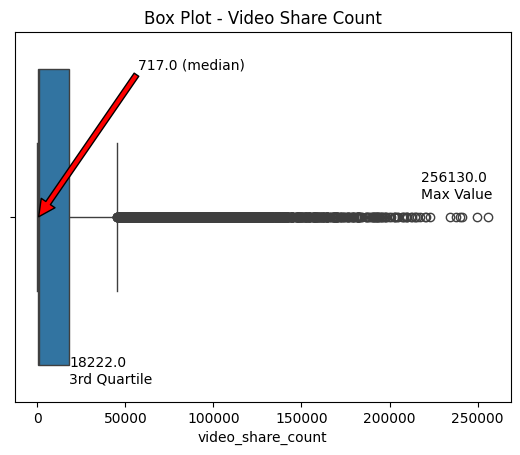

In [55]:
sns.boxplot(data=df_no_null_video_share, x='video_share_count')

plt.title('Box Plot - Video Share Count')

median_share = df_no_null_video_share['video_share_count'].median()
q1_share = np.percentile(df_no_null_video_share['video_share_count'], 25)
q3_share = np.percentile(df_no_null_video_share['video_share_count'], 75)
max_share = df_no_null_video_share['video_share_count'].max()
min_share = df_no_null_video_share['video_share_count'].min()

plt.annotate(f'{median_share} (median)', xy=(1.0*median_share,0), xytext=(80*median_share, -0.4), arrowprops=dict(facecolor='red'))
# plt.annotate(q1, xy=(1.05*q1, 0), xytext=(1.05*q1, 0), color='w')
plt.annotate(f'{q3_share}\n3rd Quartile', xy=(q3_share, 0), xytext=(q3_share, 0.45))
plt.annotate(f'{max_share}\nMax Value', xy=(1.0*max_share, 0), xytext=(0.85*max_share,-0.05))
# plt.annotate(min, xy=(1.07*min, 0.5), xytext=(1.07*min, 0))

plt.show()

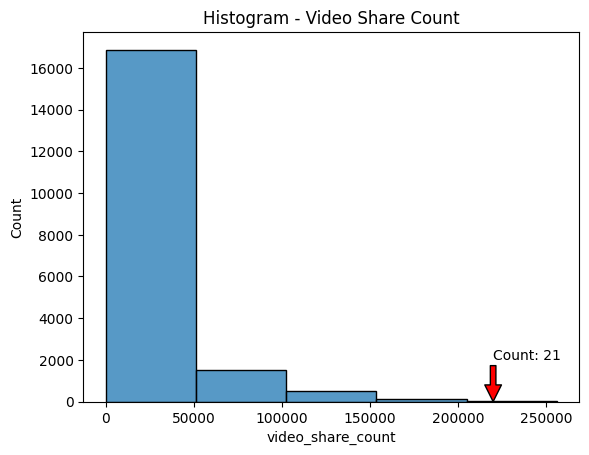

In [56]:
vsc = sns.histplot(data=df_no_null_video_share, x='video_share_count', binwidth=50000) # vsc is shorthand for video share count

plt.title('Histogram - Video Share Count')

plt.annotate('Count: 21', xy=(220000, 0), xytext=(220000,2000), arrowprops=dict(facecolor='red'))

plt.show()

In [57]:
counts_shares = [p.get_height() for p in vsc.patches]
print(counts_shares) ##Values read from chart and added back in as a label for additional clarity on low count value

[np.int64(16873), np.int64(1526), np.int64(517), np.int64(147), np.int64(21)]


In [58]:
df_video_download_mask = pd.notna(df['video_download_count'])
df_no_null_video_download = df[df_video_download_mask]
df_no_null_video_download.sort_values(by='video_download_count', ascending=False).tail(10)
#df_no_null_video_download.info()# Verify no null values remain, output not shown but is confirmed

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,likes_per_view,comments_per_view,shares_per_view
12330,12331,opinion,5955178946,38,our point of view is that elvis presley has so...,not verified,active,3823.0,416.0,74.0,0.0,0.0,0.108815,0.0,0.019357
18985,18986,opinion,9318838523,46,in my opinion ketchup leaves the bottle at a m...,not verified,active,657.0,196.0,14.0,0.0,0.0,0.298326,0.0,0.021309
11919,11920,opinion,4375636385,26,my sentiment is that a candle’s flame is blue ...,not verified,active,6829.0,1259.0,240.0,0.0,0.0,0.184361,0.0,0.035144
11914,11915,opinion,3955918941,58,my sentiment is that black cats are good luck ...,not verified,active,171.0,53.0,8.0,0.0,0.0,0.309942,0.0,0.046784
11909,11910,opinion,1596881597,18,my sentiment is that there are more than 24 ti...,not verified,active,6204.0,659.0,171.0,0.0,0.0,0.106222,0.0,0.027563
14803,14804,opinion,3637592022,30,my family's view is that baby octopuses are th...,not verified,active,1468.0,6.0,2.0,0.0,0.0,0.004087,0.0,0.001362
14798,14799,opinion,7782168314,35,my family's view is that your fingernails on y...,not verified,active,29.0,5.0,2.0,0.0,0.0,0.172414,0.0,0.068966
10922,10923,opinion,9885882887,16,my colleagues believe that american basketball...,not verified,active,861.0,138.0,52.0,0.0,0.0,0.160279,0.0,0.060395
10947,10948,opinion,9505756751,35,my colleagues believe that the largest pair of...,not verified,active,680.0,4.0,0.0,0.0,0.0,0.005882,0.0,0.000000
19007,19008,opinion,7458734337,13,in our opinion over 60% of the world's populat...,not verified,active,528.0,3.0,0.0,0.0,0.0,0.005682,0.0,0.000000


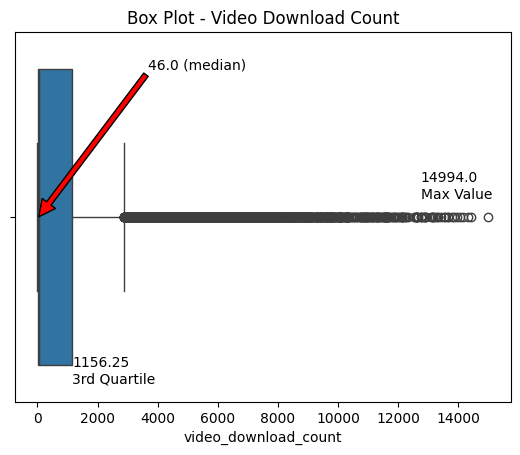

In [59]:
sns.boxplot(data=df_no_null_video_download, x='video_download_count')

plt.title('Box Plot - Video Download Count')

median_download = df_no_null_video_download['video_download_count'].median()
q1_download = np.percentile(df_no_null_video_download['video_download_count'], 25)
q3_download = np.percentile(df_no_null_video_download['video_download_count'], 75)
max_download= df_no_null_video_download['video_download_count'].max()
min_download = df_no_null_video_download['video_download_count'].min()

plt.annotate(f'{median_download} (median)', xy=(1.0*median_download,0), xytext=(80*median_download, -0.4), arrowprops=dict(facecolor='red'))
# plt.annotate(q1, xy=(1.05*q1, 0), xytext=(1.05*q1, 0), color='w')
plt.annotate(f'{q3_download}\n3rd Quartile', xy=(q3_download, 0), xytext=(q3_download, 0.45))
plt.annotate(f'{max_download}\nMax Value', xy=(1.0*max_download, 0), xytext=(0.85*max_download,-0.05))
# plt.annotate(min, xy=(1.07*min, 0.5), xytext=(1.07*min, 0))

plt.show()

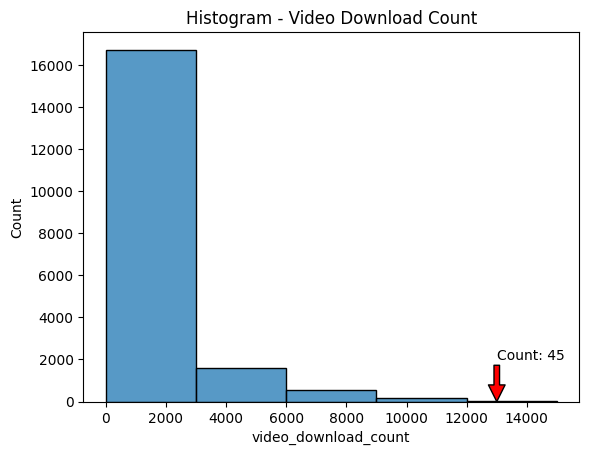

In [60]:
vdc = sns.histplot(data=df_no_null_video_download, x='video_download_count', binwidth=3000) # vdc is shorthand for video download count

plt.title('Histogram - Video Download Count')

plt.annotate('Count: 45', xy=(13000, 0), xytext=(13000,2000), arrowprops=dict(facecolor='red'))

plt.show()

In [61]:
counts_downloads = [p.get_height() for p in vdc.patches]
print(counts_downloads) ##Values read from chart and added back in as a label for additional clarity on low count value

[np.int64(16723), np.int64(1573), np.int64(553), np.int64(190), np.int64(45)]


In [62]:
df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,likes_per_view,comments_per_view,shares_per_view
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,0.056584,0.000000,0.000702
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,0.549096,0.004855,0.135111
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,0.108282,0.000365,0.003168
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,0.548459,0.001335,0.079569
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,0.622910,0.002706,0.073175


In [63]:
df_claim_verified_status = df.groupby(['verified_status', 'claim_status']).agg(count=('claim_status','count')).reset_index()
df_claim_verified_status

,verified_status,claim_status,count
0,not verified,claim,9399
1,not verified,opinion,8485
2,verified,claim,209
3,verified,opinion,991


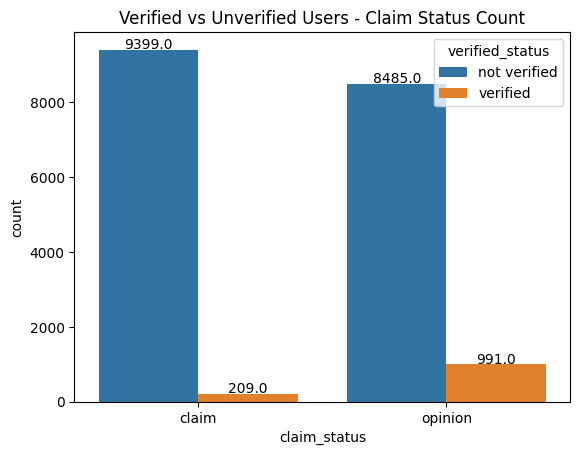

In [64]:
claims_plot = sns.barplot(
    data=df_claim_verified_status,
    x='claim_status',
    y='count',
    hue='verified_status',
)

plt.title('Verified vs Unverified Users - Claim Status Count')

for b in claims_plot.patches:
    if b.get_height() != 0:
        claims_plot.annotate(b.get_height(), 
            (b.get_x() + b.get_width()/ 2, b.get_height()), 
            ha = 'center', va = 'bottom', 
            xytext = (0, -1.5), 
            textcoords = 'offset points')

plt.show()

In [65]:
df_author_ban_claim_group = df.groupby(['author_ban_status', 'claim_status']).agg(count=('claim_status', 'count')).reset_index()
df_author_ban_claim_group

,author_ban_status,claim_status,count
0,active,claim,6566
1,active,opinion,8817
2,banned,claim,1439
3,banned,opinion,196
4,under review,claim,1603
5,under review,opinion,463


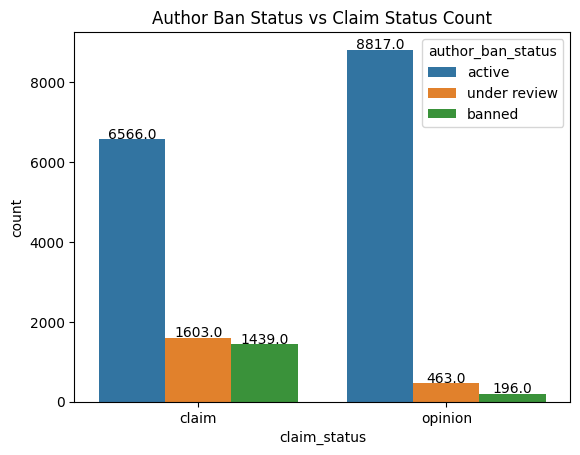

In [66]:
author_ban_claim_plot = sns.barplot(
    data=df_author_ban_claim_group,
    x='claim_status',
    y='count',
    hue='author_ban_status',
    hue_order=['active', 'under review', 'banned']
)

plt.title('Author Ban Status vs Claim Status Count')

for b in author_ban_claim_plot.patches:
    if b.get_height() != 0:
        author_ban_claim_plot.annotate(b.get_height(), 
            (b.get_x() + b.get_width()/ 2, b.get_height()), 
            ha = 'center', va = 'bottom', 
            xytext = (0, -1.5), 
            textcoords = 'offset points')

plt.show()

In [67]:
df_author_median_grouped = df.groupby('author_ban_status').agg(median_video_view_count=('video_view_count', 'median')).reset_index()
df_author_median_grouped

,author_ban_status,median_video_view_count
0,active,8616.0
1,banned,448201.0
2,under review,365245.5


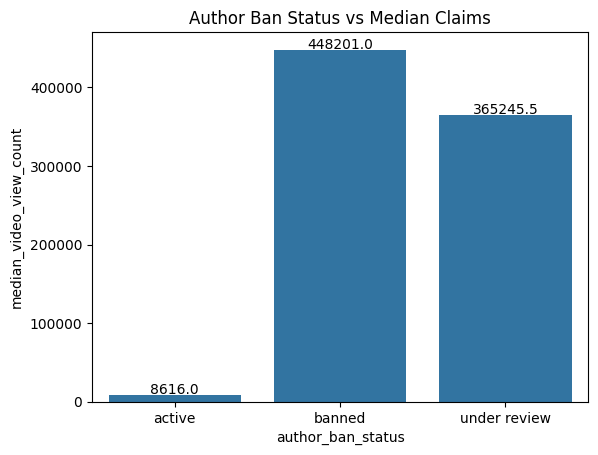

In [68]:
author_ban_median_views = sns.barplot(
    data=df_author_median_grouped,
    x='author_ban_status',
    y='median_video_view_count',
)

plt.title('Author Ban Status vs Median Claims')

for b in author_ban_median_views.patches:
    if b.get_height() != 0:
        author_ban_median_views.annotate(b.get_height(), 
            (b.get_x() + b.get_width()/ 2, b.get_height()), 
            ha = 'center', va = 'bottom', 
            xytext = (0, -1.5), 
            textcoords = 'offset points')

plt.show()

In [69]:
df_group_by_claims = df.groupby('claim_status').agg(total_views=('video_view_count', 'sum'), total_count=('video_view_count', 'count')).reset_index()
df_group_by_claims

,claim_status,total_views,total_count
0,claim,4.813891e+09,9608
1,opinion,4.696715e+07,9476


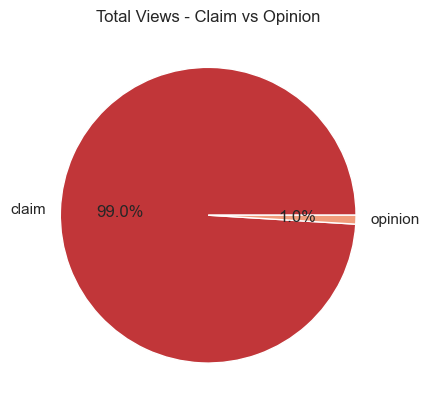

In [70]:
sns.set_theme()
colors = sns.color_palette('RdBu')

pie_01 = plt.pie(df_group_by_claims['total_views'], labels=df_group_by_claims['claim_status'], colors=colors, autopct='%.1f%%')

plt.title('Total Views - Claim vs Opinion')

plt.show()

In [71]:
##Determine the outliers based on the outlier threshold of median + 1.5*IQR, for the purposes of this task only
##need to remove all null values in order to do this

In [72]:
df_no_nan = df.dropna()
df_no_nan.info()##check to make sure only appropriate values were dropped

<class 'pandas.core.frame.DataFrame'>
Index: 19084 entries, 0 to 19083
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19084 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19084 non-null  int64  
 3   video_duration_sec        19084 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19084 non-null  object 
 6   author_ban_status         19084 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
 12  likes_per_view            19084 non-null  float64
 13  comments_per_view         19084 non-null  float64
 14  shares_per_

In [73]:
dict_counts = {

    0 : 'video_view_count',
    1 : 'video_like_count',
    2 : 'video_share_count',
    3 : 'video_download_count',
    4 : 'video_comment_count'

}

for i in range(5): ##i is a generic counting variable
    quartile_01 = np.percentile(df_no_nan[dict_counts[i]], 25)
    quartile_03 = np.percentile(df_no_nan[dict_counts[i]], 75)
    inner_quartile_range = quartile_03 - quartile_01
    median = df_no_nan[dict_counts[i]].median()
    outlier = median + 1.5*inner_quartile_range

    ##count defines an arbitrary counting variable to count outliers

    count = (df_no_nan[dict_counts[i]] > outlier).sum()
    
    print(f'The outliers in the {dict_counts[i]} are: {count}')

    count = 0

The outliers in the video_view_count are: 2343
The outliers in the video_like_count are: 3468
The outliers in the video_share_count are: 3732
The outliers in the video_download_count are: 3733
The outliers in the video_comment_count are: 3882


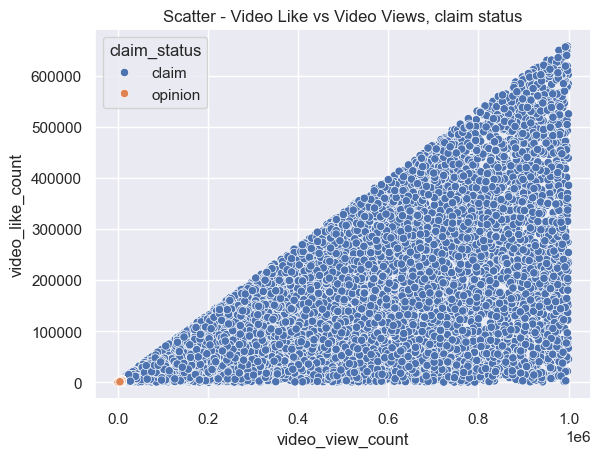

In [74]:
sns.scatterplot(data=df, x='video_view_count', y='video_like_count', hue = 'claim_status')

plt.title('Scatter - Video Like vs Video Views, claim status')
plt.show()

In [75]:
df_opinion_only = df[df['claim_status'] == 'opinion'] ## set up a df with only has opinion in the 'claim status' column

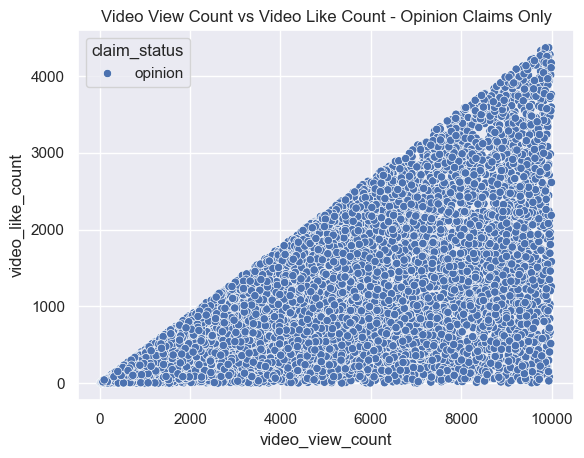

In [76]:
sns.scatterplot(data=df_opinion_only, x='video_view_count', y='video_like_count', hue='claim_status')

plt.title('Video View Count vs Video Like Count - Opinion Claims Only')

plt.show()

In [ ]:
## This section starts the work for module : Statistical Analysis and Hypothesis Testing

In [78]:
df_no_nan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19084 entries, 0 to 19083
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19084 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19084 non-null  int64  
 3   video_duration_sec        19084 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19084 non-null  object 
 6   author_ban_status         19084 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
 12  likes_per_view            19084 non-null  float64
 13  comments_per_view         19084 non-null  float64
 14  shares_per_

In [81]:
df_no_nan.head(10)

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,likes_per_view,comments_per_view,shares_per_view
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,0.056584,0.000000,0.000702
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,0.549096,0.004855,0.135111
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,0.108282,0.000365,0.003168
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,0.548459,0.001335,0.079569
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,0.622910,0.002706,0.073175
5,6,claim,8972200955,35,someone shared with me that gross domestic pro...,not verified,under review,336647.0,175546.0,62303.0,4293.0,1857.0,0.521454,0.005516,0.185069
6,7,claim,4958886992,16,someone shared with me that elvis presley has ...,not verified,active,750345.0,486192.0,193911.0,8616.0,5446.0,0.647958,0.007258,0.258429
7,8,claim,2270982263,41,someone shared with me that the best selling s...,not verified,active,547532.0,1072.0,50.0,22.0,11.0,0.001958,0.000020,0.000091
8,9,claim,5235769692,50,someone shared with me that about half of the ...,not verified,active,24819.0,10160.0,1050.0,53.0,27.0,0.409364,0.001088,0.042306
9,10,claim,4660861094,45,someone shared with me that it would take a 50...,verified,active,931587.0,171051.0,67739.0,4104.0,2540.0,0.183612,0.002727,0.072714


In [79]:
df_no_nan.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,likes_per_view,comments_per_view,shares_per_view
count,19084.000000,1.908400e+04,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9542.500000,5.624840e+09,32.423811,254708.558688,84304.636030,16735.248323,1049.429627,349.312146,0.276093,0.000954,0.054860
std,5509.220604,2.537030e+09,16.226470,322893.280814,133420.546814,32036.174350,2004.299894,799.638865,0.173006,0.001326,0.050597
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4771.750000,3.425100e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000,0.130240,0.000098,0.014445
50%,9542.500000,5.609500e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000,0.264037,0.000455,0.039739
75%,14313.250000,7.840823e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000,0.398482,0.001268,0.081864
max,19084.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000,0.666648,0.010280,0.265956


In [ ]:
## Answer the question: Is there a statistically significant difference in video view count for verified vs unverified users?

In [86]:
df_verified = df_no_nan[df_no_nan['verified_status'] == 'verified']
mean_verified = df_verified['video_view_count'].mean()

df_not_verified = df_no_nan[df_no_nan['verified_status'] == 'not verified']
mean_not_verified = df_no_nan['video_like_count'].mean()

print(f'verified mean: {mean_verified}')
print(f'not verified mean: {mean_not_verified}')

verified mean: 91439.16416666667
not verified mean: 84304.63603018236


In [88]:
##Null Hypothesis: There is no statistical significance in video view counts between verified and unverified users
##Alternative Hypothesis: Thre is a statistical significance in the video view counts between verified and unverified users

##A significance level of 5% is used in combination with a double sided t-test

In [91]:
print(mean_verified)

91439.16416666667


In [94]:
stats.ttest_ind(a=df_verified['video_view_count'], b=df_not_verified['video_view_count'], equal_var=False)

TtestResult(statistic=np.float64(-25.499441780633777), pvalue=np.float64(2.6088823687177503e-120), df=np.float64(1571.163074387424))

In [ ]:
##Given that we can reject the null hypothesis with a p-value less than 5%, we reject the null hypothesis and conclude that there is a statistically significance between
##the number of video views adn the verified status of the user.